<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/ReBeat_Visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook allows us to extract signals from the database, visualize them along with the corresponding annotations, and detect R-peaks in the ECG.


# Download Dataset


This code downloads and extracts three datasets from a public Zenodo repository into separate directories in the Colab environment. It first creates folders for raw data, filtered data, and expert annotations, then fetches the corresponding ZIP files from their URLs, saves them locally, and unzips their contents into the appropriate directories for further processing.

In [ ]:
!mkdir /content/RawData/
!wget -q https://zenodo.org/records/4725433/files/01_RawData.zip?download=1 -O /content/RawData/01_RawData.zip
!unzip -qo /content/RawData/01_RawData.zip -d /content/RawData/

!mkdir /content/FilteredData/
!wget -q https://zenodo.org/records/4725433/files/02_FilteredData.zip?download=1 -O /content/FilteredData/02_FilteredData.zip
!unzip -qo /content//FilteredData/02_FilteredData.zip -d /content//FilteredData/

!mkdir /content/Annotations/
!wget -q https://zenodo.org/records/4725433/files/03_ExpertAnnotations.zip?download=1 -O /content/Annotations/02_FilteredData.zip
!unzip -qo /content/Annotations/02_FilteredData.zip -d /content/Annotations/

mkdir: cannot create directory ‘/content/RawData/’: File exists
mkdir: cannot create directory ‘/content/FilteredData/’: File exists
mkdir: cannot create directory ‘/content/Annotations/’: File exists


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io as sio
from scipy.signal import find_peaks

Choose a file to process:

In [ ]:
subject = input("Enter subject number: ")  # example: '24'
task = input("Enter task name: ")  # 'CW' or 'BL'

filename_raw = f'/content/RawData/RawData_Subject_{subject}_task_{task}.mat'
data_raw = sio.loadmat(filename_raw)

filename_filtered = f'/content/FilteredData/FilteredData_Subject_{subject}_task_{task}.mat'
data_filtered = sio.loadmat(filename_filtered)

filename_annotation = f'/content/Annotations/Annotat_Subject_{subject}_task_{task}.mat'
annotation = sio.loadmat(filename_annotation)



Enter subject number: 24
Enter task name: CW


#Variable extraction




In [ ]:
print(data_raw.keys())
print(data_filtered.keys())
print(annotation.keys())

# raw data variables
ecg_raw = data_raw['ECG']
icg_raw = data_raw['ICG']
fs_raw = data_raw['samplFreq']

# filtered data variables
ecg_filtered = data_filtered['ECG']
icg_filtered = data_filtered['ICG']
sgf = data_filtered['SGFiltLen']
fs_filtered = data_filtered['samplFreq']
print(sgf)

# annotation variables
annotations = annotation['annotPoints']
# print(fs_raw); print(fs_filtered) fs = 250
# print(len(ecg_raw)); print(len(ecg_filtered)) number of samples = 74469
print(annotations)

dict_keys(['__header__', '__version__', '__globals__', 'ECG', 'ICG', 'samplFreq'])
dict_keys(['__header__', '__version__', '__globals__', 'ECG', 'ICG', 'SGFiltLen', 'samplFreq'])
dict_keys(['__header__', '__version__', '__globals__', 'annotPoints'])
[[9]]
[[32778 32794 32837 32858]
 [32923 32936 32983 32997]
 [33068 33080 33124 33144]
 [33213 33226 33269 33288]
 [33358 33370 33411 33425]
 [33501 33514 33556 33575]
 [33641 33654 33698 33716]
 [33782 33794 33841 33856]
 [33923 33937 33981 34000]
 [34068 34080 34120 34139]
 [15295 15310 15350 15369]
 [15430 15443 15483 15495]
 [15564 15578 15619 15632]
 [15700 15713 15754 15767]
 [15836 15850 15888 15904]
 [15975 15989 16033 16055]
 [16116 16129 16170 16187]
 [16251 16264 16304 16324]
 [16386 16399 16435 16451]
 [16521 16533 16569 16586]
 [60848 60863 60904 60917]
 [60986 61001 61044 61060]
 [61128 61140 61189 61206]
 [61269 61282 61327 61347]
 [61414 61429 61469 61482]
 [61562 61573 61616 61633]
 [61703 61716 61758 61775]
 [61845 61857 6

## Raw data plots

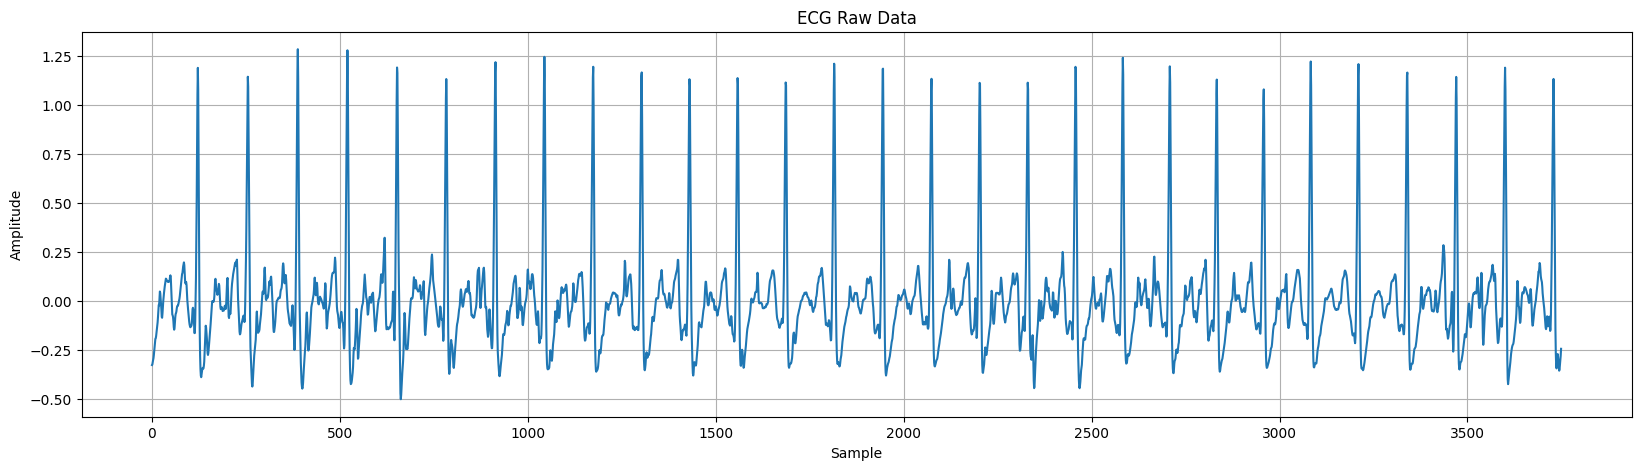

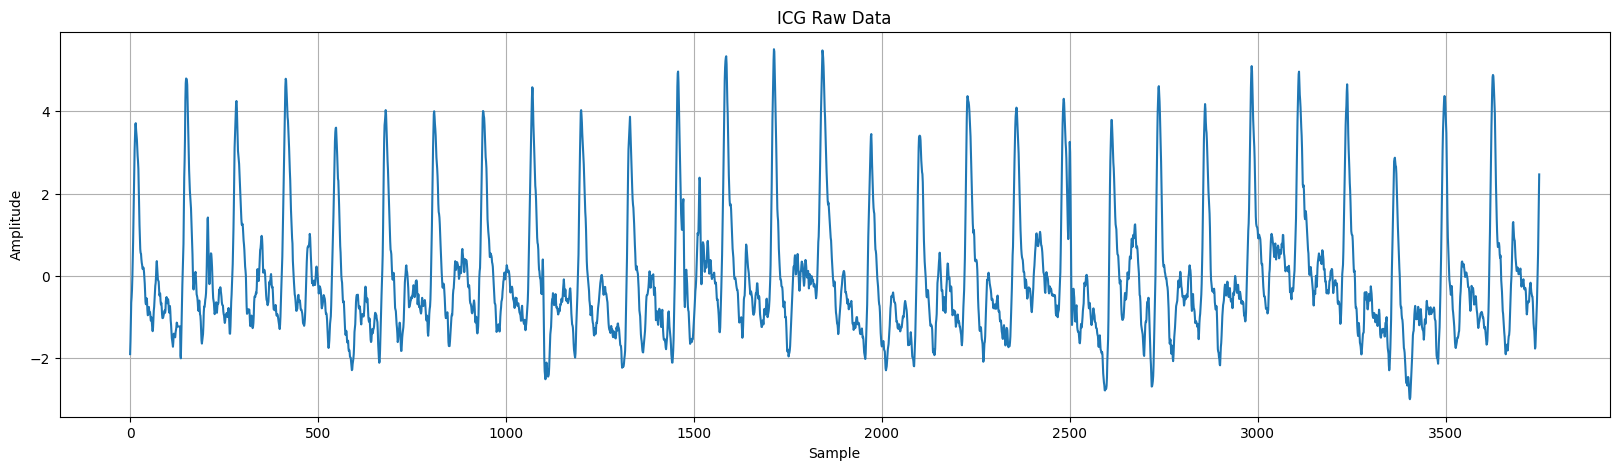

In [ ]:
# plot the ECG data
plt.figure(figsize=(20, 5))
plt.plot(ecg_raw[0:3750])
plt.title('ECG Raw Data')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# plot the ICG data
plt.figure(figsize=(20, 5))
plt.plot(icg_raw[0:3750])
plt.title('ICG Raw Data')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

## Filtered data plots

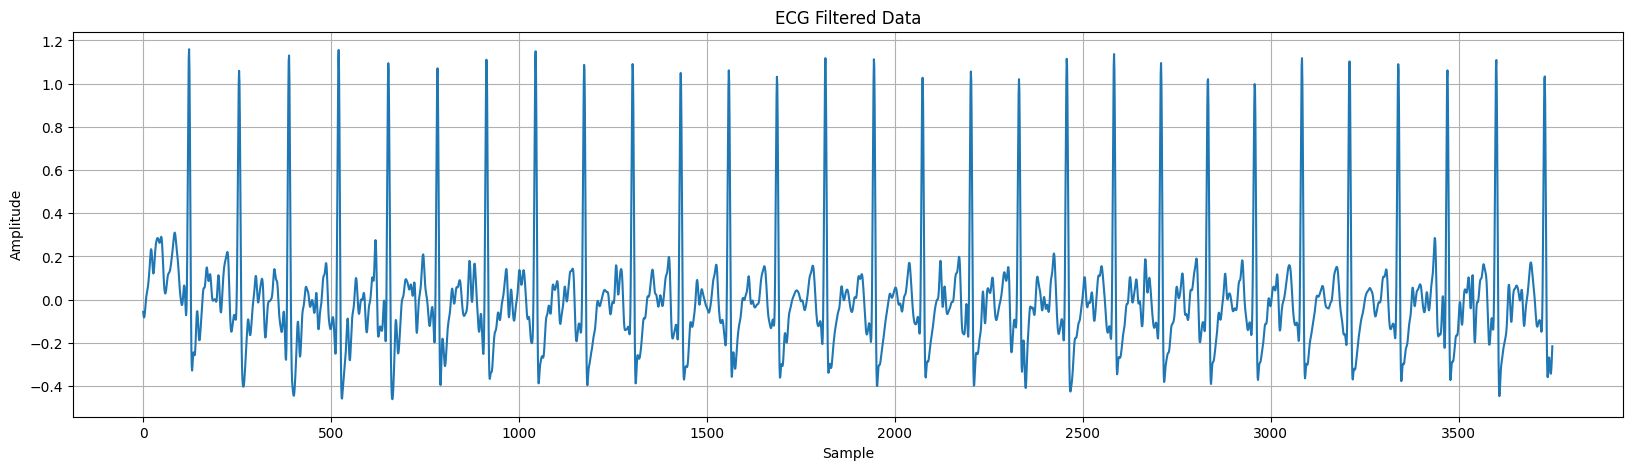

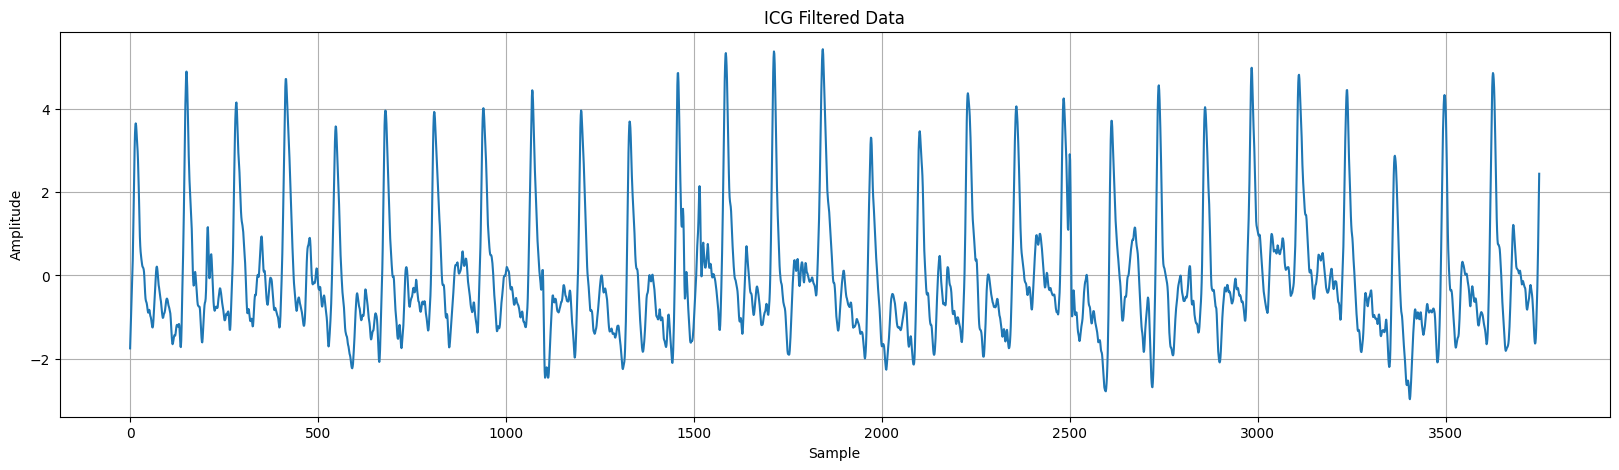

In [ ]:
# plot the ECG data
plt.figure(figsize=(20, 5))
plt.plot(ecg_filtered[0:3750])
plt.title('ECG Filtered Data')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# plot the ICG data
plt.figure(figsize=(20, 5))
plt.plot(icg_filtered[0:3750])
plt.title('ICG Filtered Data')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

## Annotations plot


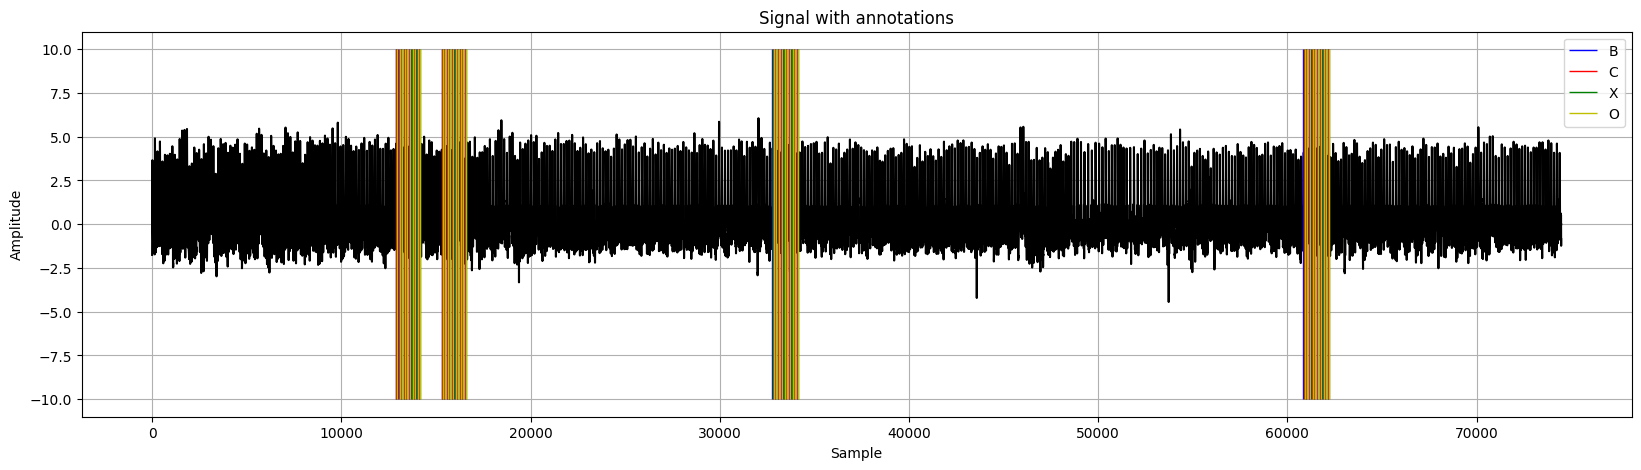

In [ ]:
samples = np.arange(0, 74470, 1)

B = annotations[:, 0]
C = annotations[:, 1]
X = annotations[:, 2]
O = annotations[:, 3]

plt.figure(figsize=(20, 5))
plt.plot(ecg_filtered,'k')
plt.plot(icg_filtered,'k') # Overlay ICG signal
plt.vlines(B, ymin=-10, ymax=10, color='b', linewidth=1, label='B')
plt.vlines(C, ymin=-10, ymax=10, color='r', linewidth=1, label='C')
plt.vlines(X, ymin=-10, ymax=10, color='g', linewidth=1, label='X')
plt.vlines(O, ymin=-10, ymax=10, color='y', linewidth=1, label='O')

plt.title('Signal with annotations')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.legend() # Add legend
plt.grid(True)
plt.show()


### Event plot with slide


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

B = annotations[:, 0]
C = annotations[:, 1]
X = annotations[:, 2]
O = annotations[:, 3]

samples = np.arange(0, 74470, 1)  # From 0 to 74469 with step 1

# Update function
def update_plot(start_sample, end_sample):
    plt.figure(figsize=(20, 3))
    plt.plot(ecg_filtered,'b',linewidth = 1)
    plt.plot(icg_filtered,'k',linewidth = 1) # Overlay ICG signal
    # Compute the min and max amplitudes for the selected range of samples
    min_amplitude = min(np.min(ecg_filtered[start_sample:end_sample]), np.min(icg_filtered[start_sample:end_sample]))
    max_amplitude = max(np.max(ecg_filtered[start_sample:end_sample]), np.max(icg_filtered[start_sample:end_sample]))

    # Plot event markers with dynamic ymin and ymax based on the min and max amplitudes
    plt.vlines(B[(B >= start_sample) & (B <= end_sample)], ymin=min_amplitude, ymax=max_amplitude, color='r', linewidth=1, label='B')  # Vertical line for event B
    plt.vlines(C[(C >= start_sample) & (C <= end_sample)], ymin=min_amplitude, ymax=max_amplitude, color='y', linewidth=1, label='C')  # Vertical line for event C
    plt.vlines(X[(X >= start_sample) & (X <= end_sample)], ymin=min_amplitude, ymax=max_amplitude, color='g', linewidth=1, label='X')  # Vertical line for event X
    plt.vlines(O[(O >= start_sample) & (O <= end_sample)], ymin=min_amplitude, ymax=max_amplitude, color='m', linewidth=1, label='O')  # Vertical line for event O

    plt.xlabel('Samples')
    plt.ylabel('Event')
    plt.ylim([-3,3])
    plt.title('Event Plot with Vertical Lines')
    plt.legend()
    plt.xlim(start_sample, end_sample)  # Limit the sample range
    plt.show()

# Create interactive sliders
start_slider = widgets.IntSlider(min=0, max=len(samples) - 100, step=10, value=0, description="Start:")
end_slider = widgets.IntSlider(min=100, max=len(samples), step=10, value=len(samples), description="End:")

# Link sliders to the update function
interactive_plot = widgets.interactive(update_plot, start_sample=start_slider, end_sample=end_slider)

# Display the sliders and the interactive plot
display(interactive_plot, start_slider, end_slider)

interactive(children=(IntSlider(value=0, description='Start:', max=74370, step=10), IntSlider(value=74470, des…

IntSlider(value=0, description='Start:', max=74370, step=10)

IntSlider(value=74470, description='End:', max=74470, min=100, step=10)

# R peak extraction


<ipython-input-31-fed8c0d35760>:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  min_distance = int(0.4 * fs)  # At least 600ms between beats (~100 bpm max)


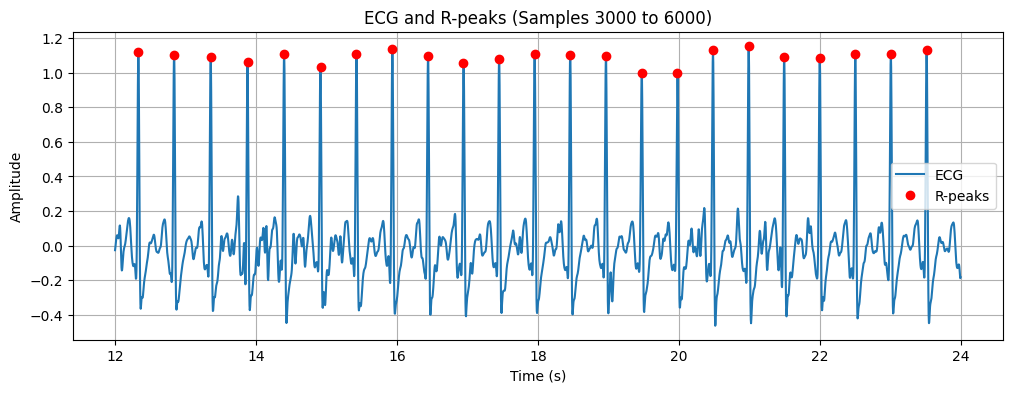

In [ ]:
def rpeak_detection(ecg, fs=250):
    """
    Detect ECG R peaks using find_peaks.

    Args:
        ecg (np.array): ECG signal
        fs (int): Sampling frequency

    Returns:
        np.array: Detected indices of R peaks
    """
    min_distance = int(0.4 * fs)  # At least 600ms between beats (~100 bpm max)
    prominence = 0.6  # we adjust based on ECG amplitude

    peaks, _ = find_peaks(ecg, distance=min_distance, prominence=prominence)
    return peaks

# Detect R peaks
r_peaks = rpeak_detection(ecg_filtered.flatten(), fs=fs_filtered)

# Time axis for plotting
times = np.arange(len(ecg_filtered)) / fs_filtered[0]

# Plot ECG and R peaks in the range 3000 to 6000 samples
plt.figure(figsize=(12, 4))
plt.plot(times[3000:6000], ecg_filtered[3000:6000], label='ECG')
valid_peaks = r_peaks[(r_peaks >= 3000) & (r_peaks < 6000)]  # Only show peaks in the selected window
plt.plot(times[valid_peaks], ecg_filtered[valid_peaks], 'ro', label='R-peaks')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('ECG and R-peaks (Samples 3000 to 6000)')
plt.legend()
plt.grid(True)
plt.show()


#Extract ICG complexes

<ipython-input-32-fe281e531786>:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pre_r = int(0.1 * fs_filtered)   # 100 ms before R
<ipython-input-32-fe281e531786>:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  post_r = int(0.4 * fs_filtered)  # 400 ms after R


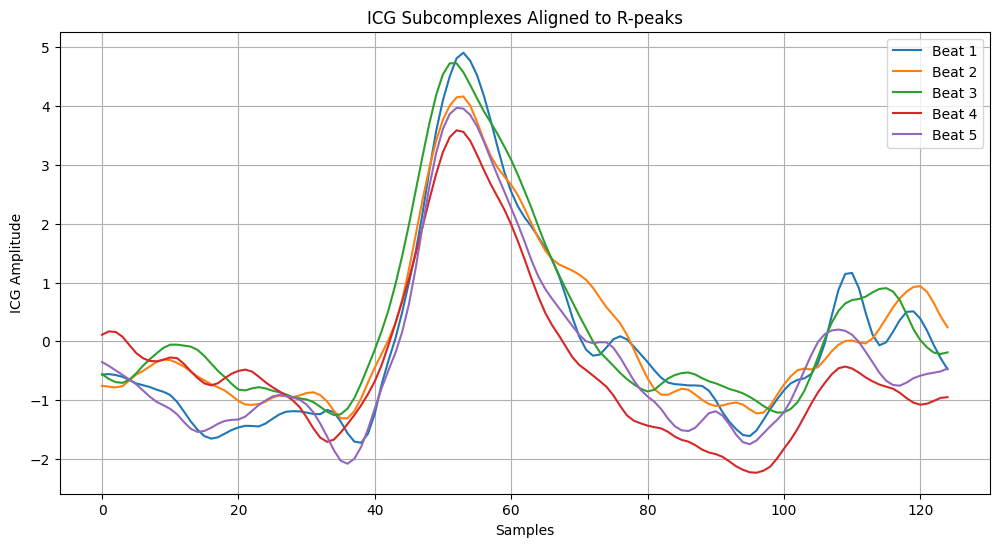

In [ ]:
pre_r = int(0.1 * fs_filtered)   # 100 ms before R
post_r = int(0.4 * fs_filtered)  # 400 ms after R
icg_segments = []

for r in r_peaks:
    start = r - pre_r
    end = r + post_r
    if start >= 0 and end < len(icg_filtered):  # avoid out-of-bound
        segment = icg_filtered[start:end]
        icg_segments.append(segment)

plt.figure(figsize=(12, 6))
for i in range(5):
    plt.plot(icg_segments[i], label=f'Beat {i+1}')
plt.title("ICG Subcomplexes Aligned to R-peaks")
plt.xlabel("Samples")
plt.ylabel("ICG Amplitude")
plt.legend()
plt.grid(True)
plt.show()


# Extract Annotated Complexes


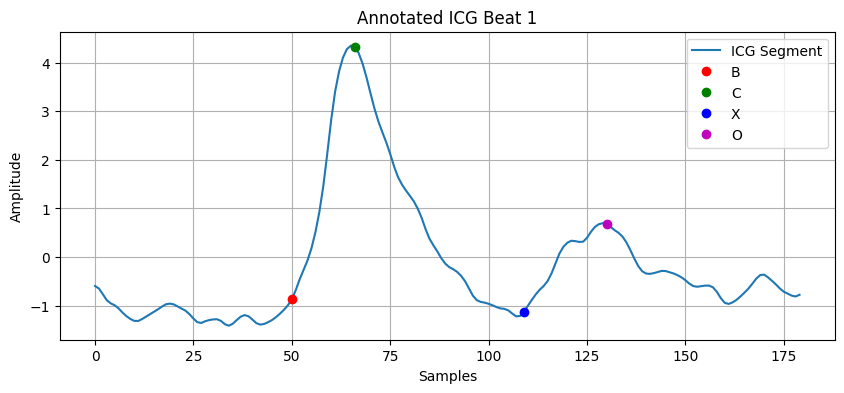

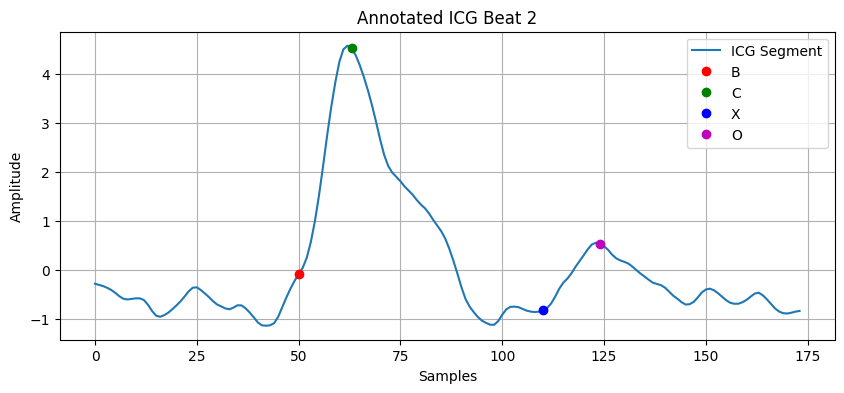

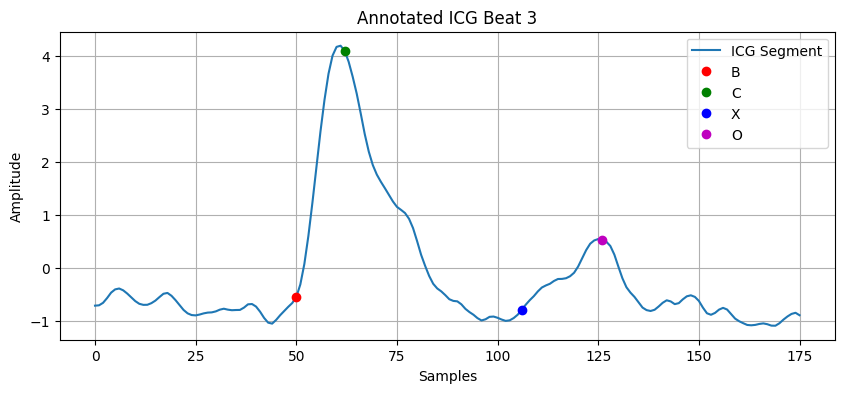

In [ ]:
annotated_segments = []
relative_annotations = []

margin = 50  # number of samples before B and after O

for row in annotations:
    b, c, x, o = row
    start = b - margin
    end = o + margin

    if start >= 0 and end < len(icg_filtered):  # avoid out-of-bounds
        segment = icg_filtered[start:end]
        annotated_segments.append(segment)

        # Save annotation indices relative to the segment
        relative = [b - start, c - start, x - start, o - start]
        relative_annotations.append(relative)


for i in range(3):  # first 3 annotated beats
    seg = annotated_segments[i]
    b, c, x, o = relative_annotations[i]

    plt.figure(figsize=(10, 4))
    plt.plot(seg, label='ICG Segment')
    plt.plot(b, seg[b], 'ro', label='B')
    plt.plot(c, seg[c], 'go', label='C')
    plt.plot(x, seg[x], 'bo', label='X')
    plt.plot(o, seg[o], 'mo', label='O')
    plt.legend()
    plt.title(f"Annotated ICG Beat {i+1}")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()
